In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_6_natural = get_prompt("natural", 6)

prompt_6_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure, and compute the RMSD, SASA, and radius of gyration of the simulation.'

In [3]:
llm_model = "gpt-4o-2024-08-06"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_6_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To address the request, I need to perform the following steps:

1. Download the PDB file for 1LYZ.
2. Set up and run a molecular dynamics simulation for 1 picosecond at 300 K.
3. Compute the secondary structure assignments using DSSP.
4. Calculate the RMSD, SASA, and radius of gyration from the simulation.

I'll start by downloading the PDB file for 1LYZ.

Action:
```json
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_214604
Thought:

To proceed with the task, I will set up and run a molecular dynamics simulation for 1 picosecond at 300 K using the downloaded PDB file for 1LYZ.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_214604",
    "forcefield_files": ["amber99sb.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "constraints": "None",
      "rigidWater": false,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 50,
      "record_params": ["step", "potentialEnergy", "temperature"]
    }
  }
}
```Building system...


About to create system...
Attempts at creating system: 0/3
adding system without solvent
Trying to add component to Forcefield...
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_214604', 'forcefield_files': ['amber99sb.xml', 'tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'NoCutoff', 'constraints': 'None', 'rigidWater': False, 'solvate': False}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 * kelvin', 'Friction': '1.0 / picoseconds', 'Timestep': '0.002 * picoseconds'}, 'simulation_params': {'Ensemble': 'NVT', 'Number of Steps': 500, 'record_interval_steps': 50, 'record_params': ['step', 'potentialEnergy', 'temperature'

Thought: The error indicates that there is an issue with missing atoms in the PDB file for residue LYS. To resolve this, I will use the CleaningToolFunction to add missing atoms and hydrogens, replace nonstandard residues, and remove heterogens and water from the PDB file. This should prepare the file for the simulation.

Action:
```json
{
  "action": "CleaningToolFunction",
  "action_input": {
    "pdb_id": "1LYZ_214604",
    "replace_nonstandard_residues": true,
    "add_missing_atoms": true,
    "remove_heterogens": true,
    "remove_water": true,
    "add_hydrogens": true
  }
}
```file path: /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_21/pdb/1LYZ_raw_20251222_214604.pdb


...

To complete the task, I need to compute the Solvent Accessible Surface Area (SASA) and determine the radius of gyration for the simulation. I will start by calculating the SASA.

Action:
```json
{
  "action": "SolventAccessibleSurfaceArea",
  "action_input": {
    "top_fileid": "1LYZ_214609",
    "traj_fileid": "rec0_214612"
  }
}
```Loading trajectory ...
Calculating SASA ...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_21/records/sasa_1LYZ_214609.csv


SASA plot saved to FIG_sasa_1LYZ_214609_20251222_214652.png

Observation: Succeeded. SASA values computed and saved with File ID sasa_1LYZ_214609. SASA analysis completed. Saved the plot with plot ID fig0_214652. 
Thought:

To finalize the task, I need to determine the radius of gyration for the simulation. I will proceed with calculating the radius of gyration using the trajectory and topology files obtained from the simulation.

Action:
```json
{
  "action": "RadiusofGyrationTool",
  "action_input": {
    "traj_file": "rec0_214612",
    "top_file": "1LYZ_214609"
  }
}
```plot_name:  FIG_rgy_rec0_214612_20251222_214654.png
plot_path /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_21/figures/FIG_rgy_rec0_214612_20251222_214654.png

Observation: Succeeded. Radii of gyration saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_21/figures/radii_of_gyration_rec0_214612.csv with id rgy_rec0_214612.Plot saved as: FIG_rgy_rec0_214612_20251222_214654.png with plot ID fig0_214654Average radius of gyration: 1.41 nm
Thought:

To summarize the results of the simulation and analyses performed on the 1LYZ protein:

1. **Secondary Structure Assignments**:
   - Residues in helix: 1461
   - Residues in strand: 323
   - Residues in coil: 2086

2. **RMSD**:
   - The RMSD was calculated and saved. The plot is available with plot ID `fig0_214640`.

3. **Solvent Accessible Surface Area (SASA)**:
   - SASA values were computed and saved. The plot is available with plot ID `fig0_214652`.

4. **Radius of Gyration**:
   - The average radius of gyration is 1.41 nm. The data is saved with ID `rgy_rec0_214612`, and the plot is available with plot ID `fig0_214654`.

These results provide a comprehensive overview of the structural dynamics of the 1LYZ protein during the 1 picosecond simulation at 300 K.

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    Y

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_214604: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_214604
 1LYZ_214609: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_214612: Initial positions for simulation sim0_214612
 sim0_214612: Basic Simulation of Protein 1LYZ_214609
 rec0_214612: Simulation trajectory for protein 1LYZ_214609 and simulation sim0_214612
 rec1_214612: Simulation state log for protein 1LYZ_214609 and simulation sim0_214612
 rec2_214612: Simulation pdb frames for protein 1LYZ_214609 and simulation sim0_214612
 rec0_214639: dssp values for trajectory with id: rec0_214612
 rmsd_1LYZ_214609: RMSD for 1LYZ_214609
 fig0_214640: RMSD plot for 1LYZ_214609
 sasa_1LYZ_214609: Total SASA values for 1LYZ_214609
 fig0_214652: Plot of SASA over time for 1LYZ_214609
 rgy_rec0_214612: Radii of gyration per frame for rec0_214612
 fig0_214654: Plot of radii of gyrati

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_214604"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_214604", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [6]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_214612")
top_path = registry.get_mapped_path("top_sim0_214612")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

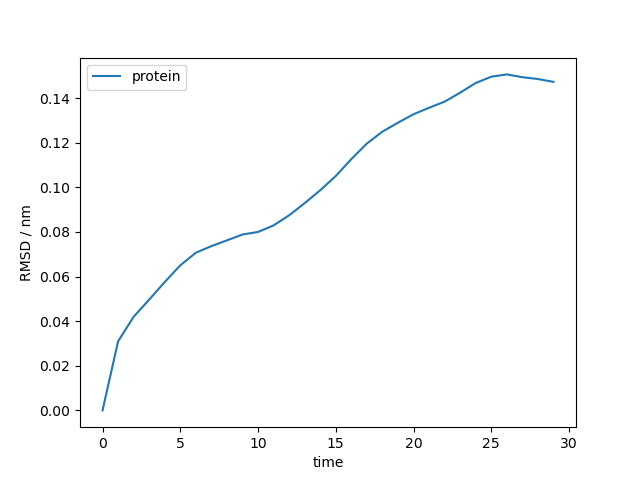

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_214640'))

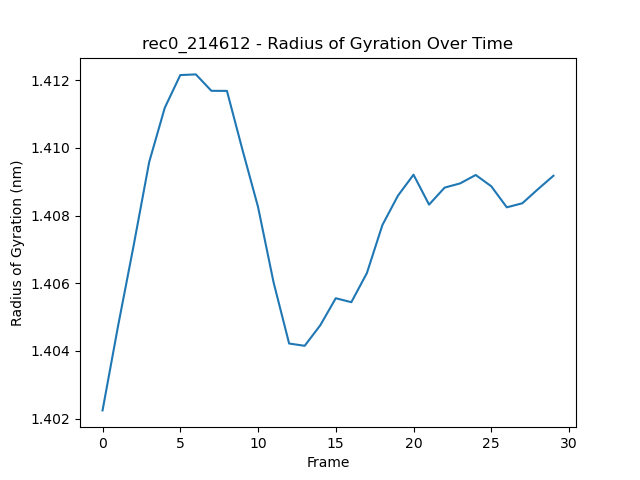

In [10]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_214654'))

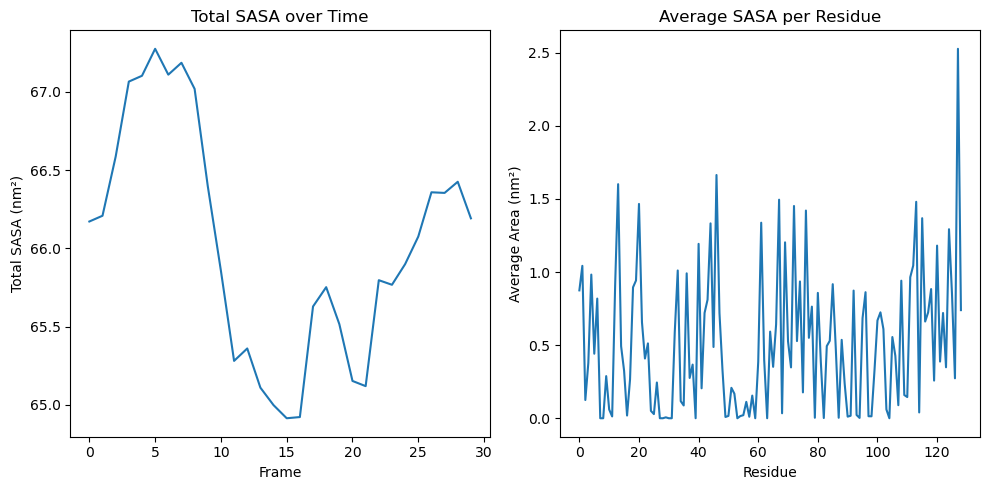

In [9]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_214652'))

In [13]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 77715
Output tokens: 1396
LLM costs: $ 0.208248
